# Predicting Popularity

importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import src.data_visualizer
import src.data_analyzer

make the dataframe

In [85]:
df = pd.read_csv("data/dataset.csv")

## basic info

the stats of some features

In [86]:
num_cols = df.select_dtypes(include='number').columns.tolist()
df.describe()

,index,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


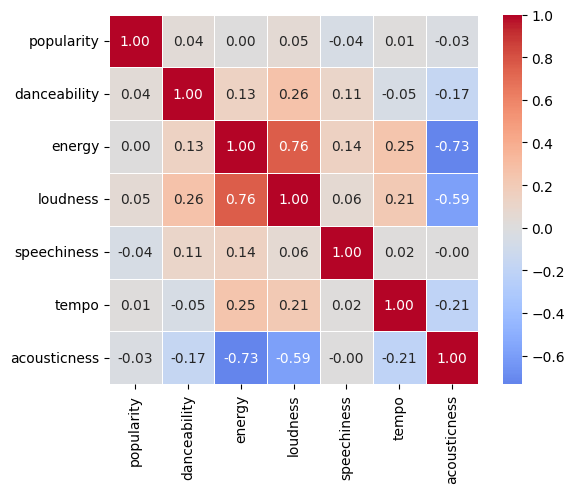

In [7]:
src.data_visualizer.plot_correlation_heatmap(df)

as we can see no real concrete correlation

We get genre and artist means

In [8]:
genre_mean =src.data_analyzer.get_genre_average(df)
genre_mean

,track_genre,avg_popularity
0,pop-film,59.28
1,k-pop,56.90
2,chill,53.65
3,sad,52.38
4,grunge,49.59
...,...,...
109,chicago-house,12.34
110,detroit-techno,11.17
111,latin,8.30
112,romance,3.24


In [9]:
artist_mean =src.data_analyzer.get_artist_average(df)
artist_mean

,artist,avg_popularity,hits,count
0,Quevedo,99.0,1,1
1,Bizarrap,99.0,1,1
2,Harry Styles,92.0,3,3
3,Luar La L,90.5,4,4
4,Beach Weather,90.0,1,1
...,...,...,...,...
29853,Bill Frisell,0.0,0,1
29854,Sarah Connor,0.0,0,29
29855,MORGAN,0.0,0,5
29856,MOSKA,0.0,0,1


we filter the artists by number of songs

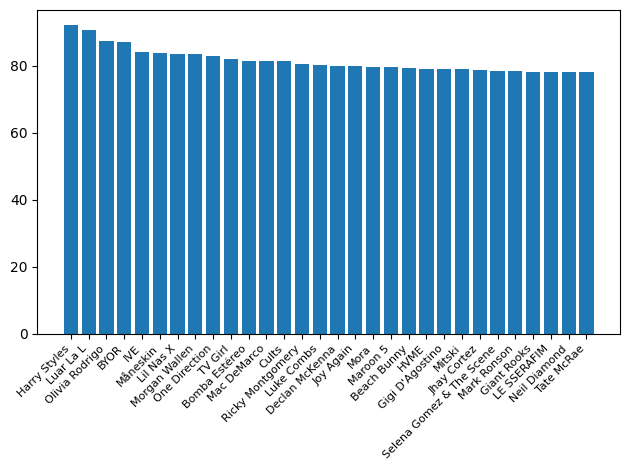

In [10]:
src.data_visualizer.artist_chart(df)

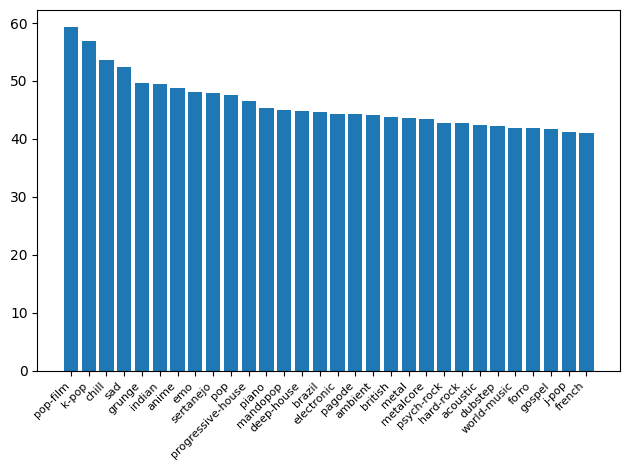

In [11]:
src.data_visualizer.genres_chart(df)

In [16]:
genre_mean_dict = genre_mean.set_index('track_genre')['avg_popularity'].to_dict()
analysis_df = df
analysis_df['genre_mean'] = df['track_genre'].map(genre_mean_dict)
analysis_df['energy*Instrumentalness'] = df['instrumentalness'] * df['energy']
analysis_df['acousticness^2'] = df['acousticness'] **2
analysis_df['valence^2'] = df['valence'] **2

In [17]:
artist_mean_dict = artist_mean.set_index('artist')['avg_popularity'].to_dict()
songs_exploded = df.assign(artist_split=df['artists'].str.split(';')).explode('artist_split')
songs_exploded['artist_mean'] = songs_exploded['artist_split'].map(artist_mean_dict)
median_artist = artist_mean['avg_popularity'].median()
songs_exploded['artist_mean'] = songs_exploded['artist_mean'].fillna(median_artist)
analysis_df['artist_mean'] = songs_exploded.groupby(songs_exploded.index)['artist_mean'].mean()

for artists we need more cleaning because there are more than one artist in a single song

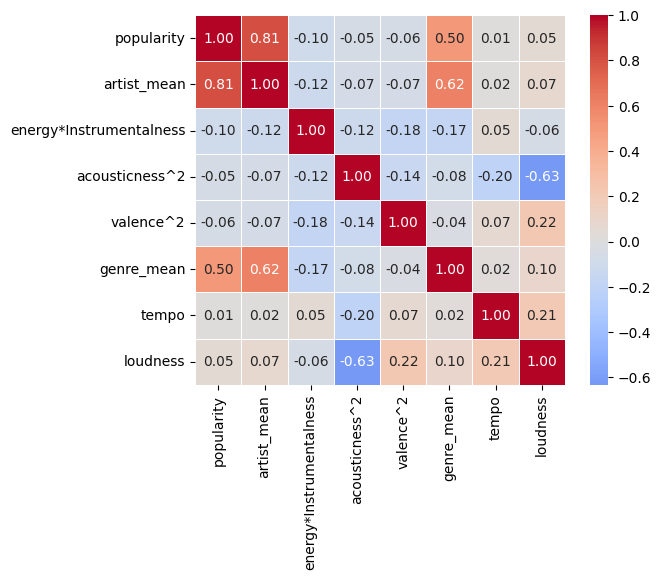

In [18]:
new_features = analysis_df[["popularity", "artist_mean","energy*Instrumentalness","acousticness^2","valence^2", "genre_mean", "tempo","loudness"]].copy()
corraltion = new_features.corr()
seaborn.heatmap(corraltion, annot=True,cmap='coolwarm',center=0,square=True,fmt='.2f',linewidths=0.5)
plt.show()

as we can see artist_mean and genre_mean have huge correlation. energy*instrumentalness and acousticness and valence on it squere form are also better features.

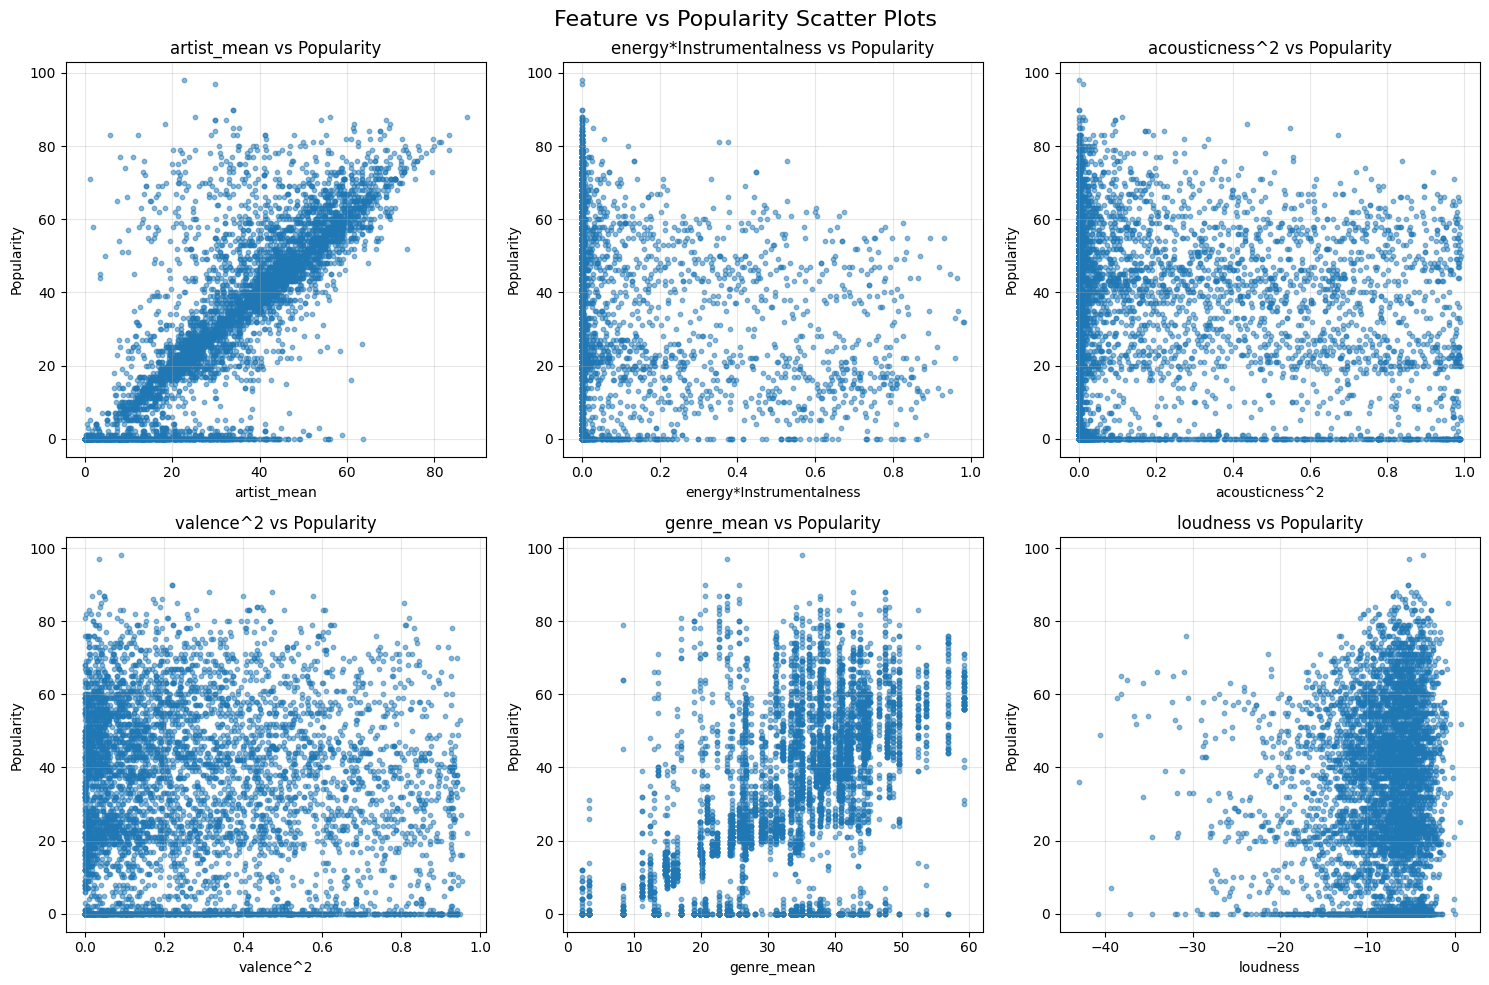

In [19]:
features = ["artist_mean","energy*Instrumentalness","acousticness^2","valence^2", "genre_mean", "loudness"]
sample_msk = np.random.rand(len(analysis_df)) < 0.05
sample_df = analysis_df[sample_msk]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature vs Popularity Scatter Plots', fontsize=16)
axes_flat = axes.flatten()
for i, feature in enumerate(features):
    ax = axes_flat[i]
    
    ax.scatter(sample_df[feature], sample_df["popularity"], alpha=0.5, s=10)
    
    
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Popularity', fontsize=10)
    ax.set_title(f'{feature} vs Popularity', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we make dataframes of popular songs and failed songs to compare them

In [20]:
super_hit_df = df[df["popularity"]>80]
super_flop_df = df[df["popularity"]<20]

we get the means of each feature in this catageries to compare them

In [21]:
super_hits_mean = super_hit_df.describe().iloc[1]
super_flops_mean = super_flop_df.describe().iloc[1]

In [22]:
stat_review = pd.DataFrame({"super_hits":super_hits_mean,"super_flops":super_flops_mean})
stat_review["diffrence(%)"] = abs(stat_review["super_hits"]-stat_review["super_flops"])/stat_review["super_flops"]*100
stat_review[2:]

,super_hits,super_flops,diffrence(%)
duration_ms,211630.045073,227925.633174,7.149520
danceability,0.658111,0.577119,14.033902
energy,0.679426,0.638868,6.348369
key,5.388889,5.369975,0.352209
loudness,-6.127299,-8.405016,-27.099497
mode,0.588050,0.628559,6.444684
speechiness,0.081458,0.081807,0.426398
acousticness,0.188535,0.301460,37.459159
instrumentalness,0.026476,0.203697,87.002145
liveness,0.168345,0.190443,11.603574


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [55]:
X = analysis_df[features]
y = analysis_df['popularity']
rand = np.random.randint(100)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
r2 = r2_score(y_test, model.predict(X_test))
print(f"R² Score: {r2:.3f} or {r2*100:.1f}%")

R² Score: 0.656 or 65.6%


In [61]:
X = analysis_df[["genre_mean","artist_mean"]]
y = analysis_df['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand)
new_model = LinearRegression()
new_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
r2 = r2_score(y_test, new_model.predict(X_test))
print(f"R² Score: {r2:.3f} or {r2*100:.1f}%")

R² Score: 0.646 or 64.6%


but there is a chance that the new song genre or artist is not in the dataset yet

In [67]:
X = analysis_df[["energy*Instrumentalness","acousticness^2","valence^2", "loudness"]]
y = analysis_df['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand)
unique_song_model = LinearRegression()
unique_song_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
r2 = r2_score(y_test, unique_song_model.predict(X_test))
print(f"R² Score: {r2:.3f} or {r2*100:.1f}%")

R² Score: 0.020 or 2.0%


very low. if we use only numbers in dataset we get

In [88]:
num_cols.remove("popularity")
num_cols.remove("index")
X = analysis_df[num_cols]
y = analysis_df['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand)
num_model = LinearRegression()
num_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
r2 = r2_score(y_test, num_model.predict(X_test))
print(f"R² Score: {r2:.3f} or {r2*100:.1f}%")

R² Score: 0.023 or 2.3%


very low. almost nonesense

if we have only genre or artist

In [98]:
X = analysis_df[["genre_mean","energy*Instrumentalness"]]
y = analysis_df['popularity']
X_train, X_genre_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand)
genre_model = LinearRegression()
genre_model.fit(X_train, y_train)

X = analysis_df[["artist_mean","energy*Instrumentalness"]]
y = analysis_df['popularity']
X_train, X_artist_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand)
artist_model = LinearRegression()
artist_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [99]:
r2 = r2_score(y_test, genre_model.predict(X_genre_test))
print(f"R² Score: {r2:.3f} or {r2*100:.1f}%")
r2 = r2_score(y_test, artist_model.predict(X_artist_test))
print(f"R² Score: {r2:.3f} or {r2*100:.1f}%")

R² Score: 0.257 or 25.7%
R² Score: 0.661 or 66.1%
